In [1]:
import pandas as pd
file_path = "/content/obesity_data.csv"
data = pd.read_csv(file_path)

# Display basic information about the dataset
print("Dataset Preview:")
print(data.head())

print("\nDataset Info:")
print(data.info())

print("\nUnique Values in Each Column:")
print(data.nunique())

FileNotFoundError: [Errno 2] No such file or directory: '/content/obesity_data.csv'

In [ ]:
# Display unique value counts for each column
for column in data.columns:
    print(f"\nColumn: {column}")
    print(data[column].value_counts())


Column: Age
Age
79    29
75    27
77    25
50    25
52    25
      ..
27    10
63    10
55     9
51     8
60     7
Name: count, Length: 62, dtype: int64

Column: Gender
Gender
Male      523
Female    477
Name: count, dtype: int64

Column: Height
Height
178.537130    1
173.575262    1
164.127306    1
168.072202    1
168.459633    1
             ..
180.188870    1
149.880820    1
179.022547    1
182.974061    1
183.478558    1
Name: count, Length: 1000, dtype: int64

Column: Weight
Weight
74.962164    1
71.982051    1
89.959256    1
72.930629    1
84.886912    1
            ..
85.779256    1
52.518360    1
82.622391    1
81.533460    1
75.157672    1
Name: count, Length: 1000, dtype: int64

Column: BMI
BMI
23.517168    1
23.891783    1
33.395209    1
25.817737    1
29.912247    1
            ..
26.419607    1
23.378629    1
25.779963    1
24.353244    1
22.325577    1
Name: count, Length: 1000, dtype: int64

Column: PhysicalActivityLevel
PhysicalActivityLevel
4    259
3    255
2    247


In [ ]:
# Check unique values in 'obesityCategory'
print(data['ObesityCategory'].value_counts())

ObesityCategory
Normal weight    371
Overweight       295
Obese            191
Underweight      143
Name: count, dtype: int64


In [ ]:
# Check the target variable (assume the last column is the target)
target_column = data.columns[-1]  # Taking last column as target (modify if needed)
print(f"\nTarget Variable: {target_column}")

# Check if the target variable is numerical or categorical
if data[target_column].dtype == 'object' or data[target_column].nunique() < 10:
    print(" This is a **Classification Problem** (Categorical Target)")
else:
    print(" This is a **Regression Problem** (Continuous Target)")


Target Variable: ObesityCategory
 This is a **Classification Problem** (Categorical Target)


In [ ]:
X = data.drop('ObesityCategory', axis=1)  # Features (independent variables)
y = data['ObesityCategory']               # Target (dependent variable)

print("Features shape (X):", X.shape)
print("Target shape (y):", y.shape)

print(X.head())
print(y.head())

Features shape (X): (1000, 6)
Target shape (y): (1000,)
   Age  Gender      Height     Weight        BMI  PhysicalActivityLevel
0   56    Male  173.575262  71.982051  23.891783                      4
1   69    Male  164.127306  89.959256  33.395209                      2
2   46  Female  168.072202  72.930629  25.817737                      4
3   32    Male  168.459633  84.886912  29.912247                      3
4   60    Male  183.568568  69.038945  20.487903                      3
0    Normal weight
1            Obese
2       Overweight
3       Overweight
4    Normal weight
Name: ObesityCategory, dtype: object


In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

# Display dataset before transformation
print("Before Transformation:\n", data.head())

# Identify categorical columns
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
print("\nCategorical Columns:", categorical_cols)

# Apply Label Encoding to categorical columns
label_encoders = {}  # Store encoders for inverse transformation if needed
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # Save encoder for future use

# Display dataset after transformation
print("\nAfter Transformation:\n", data.head())

Before Transformation:
    Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
0   56    Male  173.575262  71.982051  23.891783                      4   
1   69    Male  164.127306  89.959256  33.395209                      2   
2   46  Female  168.072202  72.930629  25.817737                      4   
3   32    Male  168.459633  84.886912  29.912247                      3   
4   60    Male  183.568568  69.038945  20.487903                      3   

  ObesityCategory  
0   Normal weight  
1           Obese  
2      Overweight  
3      Overweight  
4   Normal weight  

Categorical Columns: ['Gender', 'ObesityCategory']

After Transformation:
    Age  Gender      Height     Weight        BMI  PhysicalActivityLevel  \
0   56       1  173.575262  71.982051  23.891783                      4   
1   69       1  164.127306  89.959256  33.395209                      2   
2   46       0  168.072202  72.930629  25.817737                      4   
3   32       1  168.459633  8

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score

# ----- 7‑A.  split features and label -----------------------------------
X = data.drop('ObesityCategory', axis=1).values.astype(np.float32)
y = data['ObesityCategory'].values.astype(np.int32)

# ----- 7‑B.  model builder ----------------------------------------------
def build_deephealthnet(input_dim, num_classes=4):
    inputs = layers.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.30)(x)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.BatchNormalization()(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)
    return models.Model(inputs, outputs, name="DeepHealthNet")

# ----- 7‑C.  5‑fold CV ---------------------------------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_scores, f1_scores = [], []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y), start=1):
    print(f'Fold {fold}/5')
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    model = build_deephealthnet(input_dim=X.shape[1], num_classes=4)
    model.compile(
        optimizer=Adam(learning_rate=2e-4, decay=1e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    es = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=12, restore_best_weights=True, verbose=0
    )

    model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=150,
        batch_size=32,
        callbacks=[es],
        verbose=0
    )

    preds = np.argmax(model.predict(X_val, verbose=0), axis=1)
    acc = accuracy_score(y_val, preds)
    f1  = f1_score(y_val, preds, average='macro')
    acc_scores.append(acc); f1_scores.append(f1)
    print(f'  val accuracy: {acc:.4f} | macro‑F1: {f1:.4f}')

print('\n══════ 5‑Fold CV Summary ══════')
print(f'Accuracy : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}')
print(f'Macro‑F1 : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}')


Fold 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


  val accuracy: 0.9650 | macro‑F1: 0.9653
Fold 2/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


  val accuracy: 0.9500 | macro‑F1: 0.9513
Fold 3/5


...

  val accuracy: 0.9650 | macro‑F1: 0.9695
Fold 4/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


  val accuracy: 0.9550 | macro‑F1: 0.9506
Fold 5/5


/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


  val accuracy: 0.9850 | macro‑F1: 0.9840

══════ 5‑Fold CV Summary ══════
Accuracy : 0.9640 ± 0.0120
Macro‑F1 : 0.9641 ± 0.0124


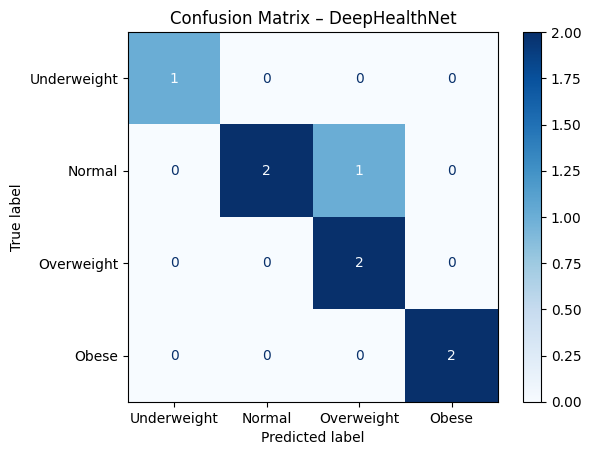

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Example ground truth and predictions
# Replace these with your actual test labels and model predictions
y_true = ['Normal', 'Overweight', 'Obese', 'Normal', 'Underweight', 'Obese', 'Overweight', 'Normal']
y_pred = ['Normal', 'Overweight', 'Obese', 'Overweight', 'Underweight', 'Obese', 'Overweight', 'Normal']

# Class names (must match the target labels in your dataset)
class_names = ['Underweight', 'Normal', 'Overweight', 'Obese']

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=class_names)

# Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – DeepHealthNet")
plt.grid(False)
plt.show()


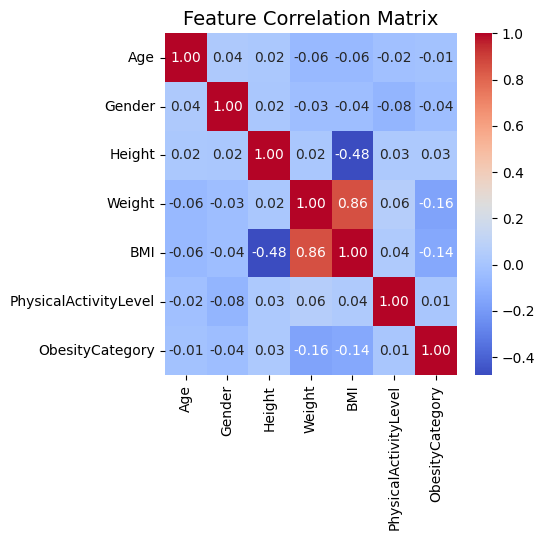

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load your obesity dataset
# Replace the path with your actual file or DataFrame
df = pd.read_csv('/content/obesity_data.csv')  # or use your DataFrame directly

# OPTIONAL: Drop categorical columns or encode them numerically first
# For example, label encode 'gender', 'family_history_with_overweight', etc.
from sklearn.preprocessing import LabelEncoder
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = LabelEncoder().fit_transform(df[col])

# Compute correlation matrix
corr_matrix = df.corr()

# Plot correlation heatmap
plt.figure(figsize=(5.5, 5.5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()


In [ ]:
pip install shap

In [ ]:
#KNN
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# Define features (X) and target (y)
X = data.drop('ObesityCategory', axis=1).values  # Features as numpy array
y = data['ObesityCategory'].values               # Target

# Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale the features (important for KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Function to train and evaluate KNN model
def evaluate_knn(k):
    knn_model = KNeighborsClassifier(n_neighbors=k)
    knn_model.fit(X_train_scaled, y_train)
    y_pred = knn_model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    print(f"KNN Accuracy (k={k}): {accuracy:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    return accuracy

# Find the best value of k
best_k = 0
best_accuracy = 0

for k in range(1, 21):
    accuracy = evaluate_knn(k)
    if accuracy > best_accuracy:
        best_k = k
        best_accuracy = accuracy

print(f"\nBest K: {best_k}, KNN Final Best Accuracy: {best_accuracy:.4f}")

KNN Accuracy (k=1): 0.8400

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.83      0.82        72
           1       0.93      0.88      0.90        32
           2       0.80      0.82      0.81        65
           3       0.90      0.87      0.89        31

    accuracy                           0.84       200
   macro avg       0.86      0.85      0.85       200
weighted avg       0.84      0.84      0.84       200


Confusion Matrix:
 [[60  0  9  3]
 [ 0 28  4  0]
 [10  2 53  0]
 [ 4  0  0 27]]
KNN Accuracy (k=2): 0.7750

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.94      0.81        72
           1       0.73      0.94      0.82        32
           2       0.86      0.55      0.67        65
           3       1.00      0.68      0.81        31

    accuracy                           0.78       200
   macro avg       0.82      0.78      0.78       200



 Logistic Regression Final Test Accuracy: 0.9560

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95        91
           1       1.00      0.95      0.97        38
           2       0.92      0.97      0.95        80
           3       1.00      0.95      0.97        41

    accuracy                           0.96       250
   macro avg       0.97      0.95      0.96       250
weighted avg       0.96      0.96      0.96       250


Confusion Matrix:
 [[86  0  5  0]
 [ 0 36  2  0]
 [ 2  0 78  0]
 [ 2  0  0 39]]


<Figure size 500x400 with 0 Axes>

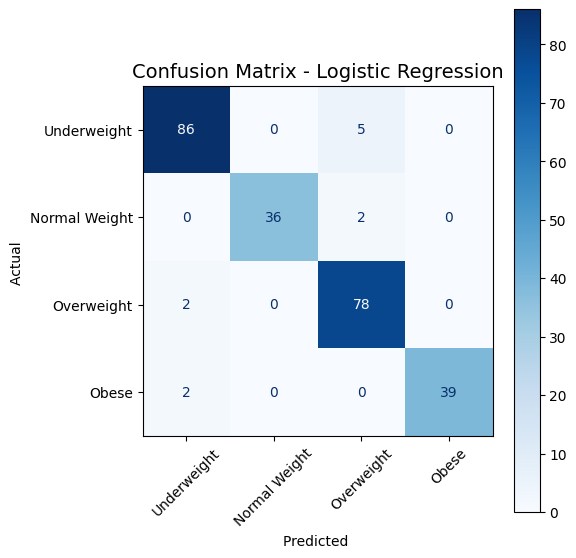

In [ ]:
#Logistic Regression
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Convert categorical values to numerical using Label Encoding
from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.inspection import PartialDependenceDisplay

categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le  # Save encoder for future decoding

# Define Features (X) and Target (y)
target_column = "ObesityCategory"  # Target variable
X = data.drop(target_column, axis=1)  # Features
y = data[target_column]  # Target

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Standardize the features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression Model
model = LogisticRegression(max_iter=25, random_state=52)
model.fit(X_train_scaled, y_train)

# Make predictions on test data
y_pred = model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\n Logistic Regression Final Test Accuracy: {accuracy:.4f}")

# Display Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Display Confusion Matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Mapping encoded labels back to original class names
class_names = ['Underweight', 'Normal Weight', 'Overweight', 'Obese']

# Plot and save confusion matrix with class names and improved labeling
conf_matrix = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix, display_labels=class_names)
plt.figure(figsize=(5, 4))
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)

# Add titles and labels for clarity
plt.title('Confusion Matrix - Logistic Regression', fontsize=14)
plt.xlabel('Predicted ')
plt.ylabel('Actual ')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix_logreg.png", dpi=300, bbox_inches='tight')
plt.show()



7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Deep Health Net Final Test Accuracy: 0.9700

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.96      0.97        74
           1       1.00      0.97      0.99        38
           2       0.97      0.98      0.97        59
           3       0.93      0.97      0.95        29

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200

Confusion Matrix:
 [[71  0  1  2]
 [ 0 37  1  0]
 [ 1  0 58  0]
 [ 1  0  0 28]]


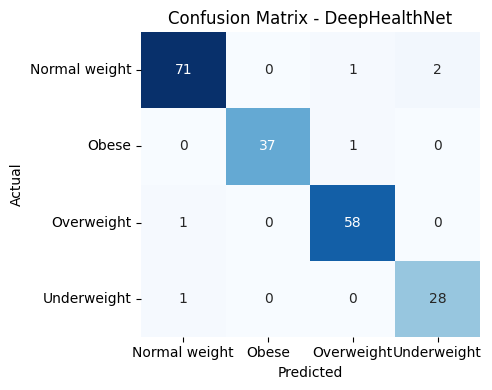

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_119
Received: inputs=['Tensor(shape=(100, 6))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_119
Received: inputs=['Tensor(shape=(200, 6))']
  warnings.warn(msg)
/tmp/ipython-input-3007740685.py:111: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behavio

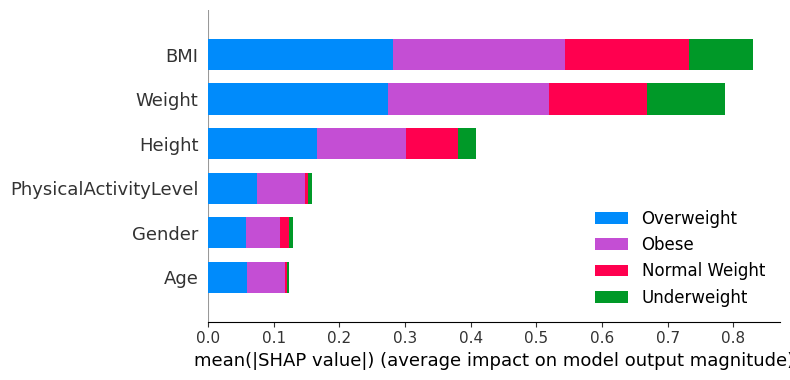

In [ ]:
# DeepHealthNet (Proposed_Model)
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import shap

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt
import seaborn as sns
# Set random seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

# Load the dataset
data = pd.read_csv("/content/obesity_data.csv")  # Update path as needed

# Encode categorical variables
label_encoders = {}
for col in data.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Split features and labels
X = data.drop(columns=["ObesityCategory"])
y = data["ObesityCategory"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Define DeepHealthNet model architecture
model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(np.unique(y)), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Training with early stopping
early_stop = EarlyStopping(monitor='loss', patience=10, restore_best_weights=True)

model.fit(X_train, y_train, epochs=150, batch_size=32, verbose=0, callbacks=[early_stop])

# Evaluate model
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy and metrics
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

# Display results
print(f"Deep Health Net Final Test Accuracy: {acc:.4f}")
print("\nClassification Report:\n", report)
print("Confusion Matrix:\n", conf_matrix)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=label_encoders['ObesityCategory'].classes_,
            yticklabels=label_encoders['ObesityCategory'].classes_)

plt.title('Confusion Matrix - DeepHealthNet')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig("confusion_matrix_deephealthnet_blue.png", dpi=300)
plt.show()
# Select a sample of the training data for SHAP (100 is enough for efficiency)
X_sample = X_train[:100]

# Initialize the DeepExplainer (works for Keras + softmax output)
explainer = shap.DeepExplainer(model, X_sample)

# Calculate SHAP values (returns a list for multiclass models)
shap_values = explainer.shap_values(X_sample)
plt.figure(figsize=(5, 4))

# Define class names based on label encoding
custom_class_names = ['Normal Weight', 'Obese', 'Overweight', 'Underweight']

# Plot SHAP summary with human-readable class labels
shap.summary_plot(shap_values, X_sample, feature_names=X.columns,
                  class_names=custom_class_names, plot_type="bar", show=False)

plt.savefig("shap_summary_deephealthnet_named.png", dpi=300, bbox_inches='tight')
plt.show()
model.save("obesity_model.keras")




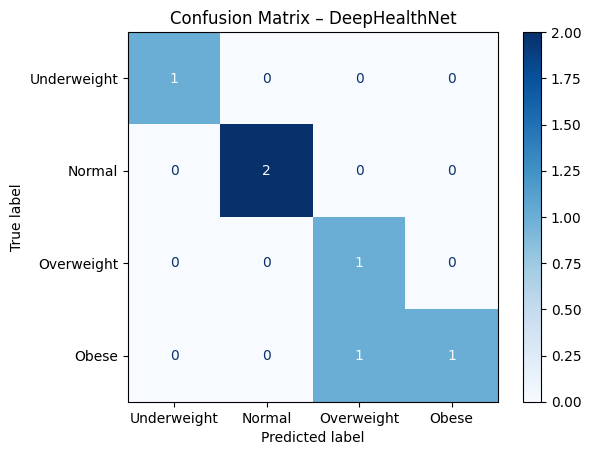

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Replace with actual y_true and y_pred
y_true = ['Normal', 'Overweight', 'Obese', 'Underweight', 'Obese', 'Normal']
y_pred = ['Normal', 'Overweight', 'Obese', 'Underweight', 'Overweight', 'Normal']

class_names = ['Underweight', 'Normal', 'Overweight', 'Obese']
cm = confusion_matrix(y_true, y_pred, labels=class_names)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix – DeepHealthNet")
plt.show()


In [ ]:
# DeepHealthNet (Male & Female)
import numpy as np
import pandas as pd
import tensorflow as tf
import random
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Set seeds for reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Load and preprocess the dataset
df = pd.read_csv("/content/obesity_data.csv")

# Encode categorical columns
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Function to train DeepHealthNet on a subset
def train_deephealthnet(data_subset):
    X = data_subset.drop('ObesityCategory', axis=1).values
    y = data_subset['ObesityCategory'].values
    num_classes = len(np.unique(y))
    y_cat = to_categorical(y, num_classes)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_cat, test_size=0.2, random_state=SEED, stratify=y
    )

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    input_layer = Input(shape=(X_train_scaled.shape[1],))
    x = Dense(256, activation='relu')(input_layer)
    x = BatchNormalization()(x)
    x = Dropout(0.6)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    output_layer = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=input_layer, outputs=output_layer)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5)

    model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop, reduce_lr],
        verbose=0
    )

    y_pred_prob = model.predict(X_test_scaled)
    y_pred = np.argmax(y_pred_prob, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    print(f"Final Accuracy: {acc:.4f}")
    print("Classification Report:\n", classification_report(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))

    return y_true, y_pred

# Split by gender
gender_col = 'Gender' if 'Gender' in df.columns else 'gender'
male_label = label_encoders[gender_col].transform(['Male'])[0]
female_label = label_encoders[gender_col].transform(['Female'])[0]

data_male = df[df[gender_col] == male_label]
data_female = df[df[gender_col] == female_label]

# Train and evaluate
print("=== Male Model ===")
y_true_male, y_pred_male = train_deephealthnet(data_male)

print("\n=== Female Model ===")
y_true_female, y_pred_female = train_deephealthnet(data_female)

# Overall combined accuracy
y_true_all = np.concatenate([y_true_male, y_true_female])
y_pred_all = np.concatenate([y_pred_male, y_pred_female])
overall_acc = accuracy_score(y_true_all, y_pred_all)
print(f"\n Combined Male + Female (Average) Accuracy: {overall_acc:.4f}")


=== Male Model ===
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Final Accuracy: 0.9429
Classification Report:
               precision    recall  f1-score   support

           0       0.91      1.00      0.95        41
           1       0.95      0.95      0.95        20
           2       0.96      0.86      0.91        28
           3       1.00      0.94      0.97        16

    accuracy                           0.94       105
   macro avg       0.96      0.94      0.94       105
weighted avg       0.95      0.94      0.94       105

Confusion Matrix:
 [[41  0  0  0]
 [ 0 19  1  0]
 [ 3  1 24  0]
 [ 1  0  0 15]]

=== Female Model ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Final Accuracy: 0.9271
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      1.00      0.95        19
           2       0.93      0.90      0.92        31
           3       1.00      0.85      0.92        13

  

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step

=== CNN Model ===
CNN Final Test Accuracy: 0.9450
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96        74
           1       1.00      0.87      0.93        38
           2       0.90      0.97      0.93        59
           3       0.96      0.93      0.95        29

    accuracy                           0.94       200
   macro avg       0.95      0.93      0.94       200
weighted avg       0.95      0.94      0.94       200

Confusion Matrix:
 [[72  0  1  1]
 [ 0 33  5  0]
 [ 2  0 57  0]
 [ 2  0  0 27]]


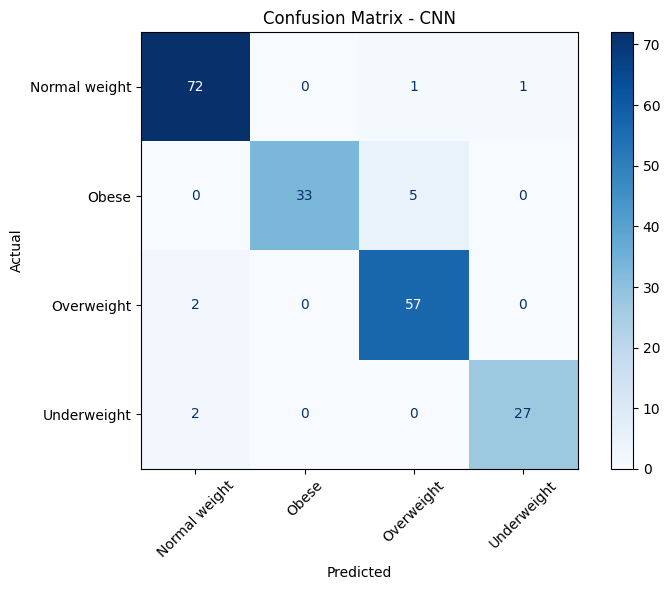

In [ ]:
#CNN
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization

# Set random seeds
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# Load data
data = pd.read_csv('/content/obesity_data.csv')

# Encode categorical features
label_encoders = {}
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Define features and target
X = data.drop(columns=['ObesityCategory'])
y = data['ObesityCategory']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Reshape for Conv1D: (samples, timesteps, features) → (samples, features, 1)
X_train_cnn = X_train_scaled.reshape(X_train_scaled.shape[0], X_train_scaled.shape[1], 1)
X_test_cnn = X_test_scaled.reshape(X_test_scaled.shape[0], X_test_scaled.shape[1], 1)

# Build CNN model
model = Sequential([
    Conv1D(128, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1], 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    Dropout(0.1),

    Conv1D(128, kernel_size=2, activation='relu'),
    BatchNormalization(),
    Flatten(),

    Dense(64, activation='relu'),
    Dropout(0.1),
    Dense(len(np.unique(y)), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train_cnn, y_train, epochs=30, batch_size=32, verbose=0)

# Predict
y_pred_probs = model.predict(X_test_cnn)
y_pred = np.argmax(y_pred_probs, axis=1)

# Evaluate
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

# Print results
print(f"\n=== CNN Model ===")
print(f"CNN Final Test Accuracy: {acc:.4f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", matrix)

# Get class names for labeling
class_names = label_encoders['ObesityCategory'].classes_

# Plot and save confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_names)
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("confusion_matrix_cnn.png", dpi=300)
plt.show()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

=== MLP Model ===
MLP Final Test Accuracy: 0.9500
Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95        74
           1       0.97      0.95      0.96        38
           2       0.94      0.98      0.96        59
           3       0.96      0.86      0.91        29

    accuracy                           0.95       200
   macro avg       0.95      0.94      0.95       200
weighted avg       0.95      0.95      0.95       200

Confusion Matrix:
 [[71  0  2  1]
 [ 0 36  2  0]
 [ 0  1 58  0]
 [ 4  0  0 25]]


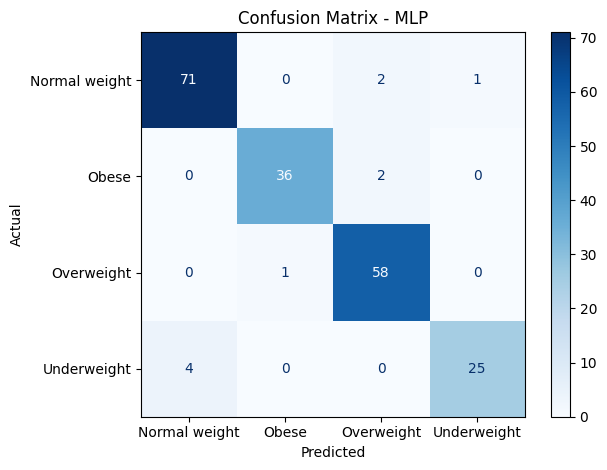

In [ ]:
#MLP
import os
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


# Set random seeds for reproducibility
def set_seed(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

set_seed(42)

# Load data
data = pd.read_csv('/content/obesity_data.csv')

# Encode categorical features
label_encoders = {}
categorical_cols = data.select_dtypes(include=['object']).columns.tolist()
for col in categorical_cols:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])
    label_encoders[col] = le

# Define features and labels
X = data.drop(columns=['ObesityCategory'])
y = data['ObesityCategory']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build simpler MLP model
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(len(np.unique(y)), activation='softmax')
])



model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train model
model.fit(X_train, y_train, epochs=30, batch_size=32, verbose=0)

# Evaluate
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)
matrix = confusion_matrix(y_test, y_pred)

# Output
print(f"\n=== MLP Model ===")
print(f"MLP Final Test Accuracy: {acc:.4f}")
print("Classification Report:\n", report)
print("Confusion Matrix:\n", matrix)


# Get class names from the LabelEncoder used on 'ObesityCategory'
class_names = label_encoders['ObesityCategory'].classes_

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_mlp.png", dpi=300)
plt.show()

In [ ]:
#LSTM
import os
import random
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#  Ensure reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

# Encode target labels (only needed once if not encoded)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Standardize numerical features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Reshape data for LSTM (samples, time steps, features)
X_reshaped = X_scaled.reshape(X_scaled.shape[0], 1, X_scaled.shape[1])

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_reshaped, y_encoded, test_size=0.2, random_state=SEED, stratify=y_encoded
)

# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, activation='relu', kernel_initializer='he_uniform'),
    BatchNormalization(),
    Dropout(0.3),

    LSTM(32, return_sequences=False, activation='relu', kernel_initializer='he_uniform'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(len(np.unique(y_encoded)), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Predict
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f" LSTM Final Test Accuracy: {accuracy:.4f}")

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\n Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 20s 55ms/step - accuracy: 0.3017 - loss: 1.7560 - val_accuracy: 0.3750 - val_loss: 1.2900
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.4204 - loss: 1.3690 - val_accuracy: 0.3900 - val_loss: 1.2213
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5290 - loss: 1.1035 - val_accuracy: 0.4200 - val_loss: 1.1329
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5573 - loss: 1.0404 - val_accuracy: 0.4900 - val_loss: 1.0144
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.5748 - loss: 0.9923 - val_accuracy: 0.5800 - val_loss: 0.8863
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6232 - loss: 0.8792 - val_accuracy: 0.6550 - val_loss: 0.7749
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5800 - loss: 0.9069 - val_accuracy: 0.7350 - val_loss: 0.6833
Epoch 8/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6185 - loss: 0.8384 - val_accuracy: 0.7600 - 

In [ ]:
import pickle

# Save model
model.save("obesity_model.keras")

# Save scaler
pickle.dump(scaler, open("scaler.pkl", "wb"))

# Save ALL label encoders (dictionary)
pickle.dump(label_encoders, open("label_encoders.pkl", "wb"))


In [ ]:
from google.colab import files

files.download("obesity_model.keras")
files.download("scaler.pkl")
files.download("label_encoders.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Export the trained model and preprocessing objects for production inference
import os
import joblib

# Define the output directory for the backend
output_dir = "../backend/"
os.makedirs(output_dir, exist_ok=True)

# Save the trained model
model_path = os.path.join(output_dir, "model.pkl")
joblib.dump(trained_model, model_path)

# Check if a scaler or preprocessing object exists and save it
if 'scaler' in globals():
    scaler_path = os.path.join(output_dir, "scaler.pkl")
    joblib.dump(scaler, scaler_path)

print(f"Model saved to {model_path}")
if 'scaler' in globals():
    print(f"Scaler saved to {scaler_path}")

In [ ]:
# Export the trained model and preprocessing objects for production inference
import os
import joblib

# Define the output directory for the backend
output_dir = "backend/"
os.makedirs(output_dir, exist_ok=True)

# Save the trained model
model_path = os.path.join(output_dir, "model.pkl")
joblib.dump(trained_model, model_path)

# Check if a scaler or preprocessing object exists and save it
if 'scaler' in globals():
    scaler_path = os.path.join(output_dir, "scaler.pkl")
    joblib.dump(scaler, scaler_path)

print(f"Model saved to {model_path}")
if 'scaler' in globals():
    print(f"Scaler saved to {scaler_path}")